<a href="https://colab.research.google.com/github/sk27110/DL2/blob/HW2/HW2_DEER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/bflashcp3f/deer.git

Cloning into 'deer'...
remote: Enumerating objects: 84, done.
remote: Counting objects: 100% (84/84), done.
remote: Compressing objects: 100% (52/52), done.
remote: Total 84 (delta 35), reused 73 (delta 30), pack-reused 0 (from 0)
Receiving objects: 100% (84/84), 8.90 MiB | 16.91 MiB/s, done.
Resolving deltas: 100% (35/35), done.


In [ ]:
%cd deer

/content/deer


В качестве LLM возьмем Qwen 2.5 7B (в статье кажется использовалась Qwen 2)

In [ ]:
import subprocess
import time

!sudo apt-get update -qq && sudo apt-get install -y zstd -qq
!curl -fsSL https://ollama.com/install.sh | sh

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package zstd.
(Reading database ... 122402 files and directories currently installed.)
Preparing to unpack .../zstd_1.4.8+dfsg-3build1_amd64.deb ...
Unpacking zstd (1.4.8+dfsg-3build1) ...
Setting up zstd (1.4.8+dfsg-3build1) ...
Processing triggers for man-db (2.10.2-1) ...
>>> Installing ollama to /usr/local
>>> Downloading ol

In [ ]:
process = subprocess.Popen(["ollama", "serve"], stdout=subprocess.PIPE, stderr=subprocess.PIPE)
time.sleep(5)
!ollama pull qwen2.5:7b

Заниматься своей разметкой датасета было очень лень, поэтому возьмем подвыборку из датасета TweetNER7 (100 примеров на обучение и 30 примеров на тест). Этого хватит, чтобы поиграться с методом.

In [ ]:
!tar -xzf deer_data.tar.gz

import json, os

!ls data/tweetner7/

with open("data/tweetner7/train.jsonl", "r") as f:
    train_all = [json.loads(l) for l in f.readlines()]

small_train = train_all[:100]
with open("data/tweetner7/train_small.jsonl", "w") as f:
    for item in small_train:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")

with open("data/tweetner7/test.jsonl", "r") as f:
    test_all = [json.loads(l) for l in f.readlines()]

small_test = test_all[:30]
eval_split = "test_sample_1000"
with open(f"data/tweetner7/{eval_split}.jsonl", "w") as f:
    for item in small_test:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")

!mv data/tweetner7/train.jsonl data/tweetner7/train_full.jsonl
!mv data/tweetner7/train_small.jsonl data/tweetner7/train.jsonl

print(f"Готово: train ({len(small_train)}), test ({len(small_test)})")


test.jsonl  train.jsonl  validation.jsonl
Готово: train (100), test (30)


In [ ]:
!OPENAI_BASE_URL="http://localhost:11434/v1" OPENAI_API_KEY="ollama" PYTHONPATH="src" python run.py \
    --data_name tweetner7 \
    --output_dir my_results \
    --model_type openai \
    --model_name qwen2.5:7b \
    --emb_model_type sbert \
    --emb_model_name all-MiniLM-L6-v2 \
    --prompt_template_name icl_json_format \
    --icl_demo_retrieval_method kate \
    --icl_demo_num 8 \
    --icl_inference \
    --no_async_mode \
    --eval_split test_sample_1000 \
    --batch_size 1

2026-05-30 22:30:16.825249: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Namespace(data_name='tweetner7', output_dir='my_results', emb_model_type='sbert', emb_model_name='all-MiniLM-L6-v2', emb_batch_size=128, emb_sleep_time=1, train_num=None, eval_split='test_sample_1000', eval_num=None, sample_seed=42, icl_inference=True, model_type='openai', model_name='qwen2.5:7b', prompt_template_name='icl_json_format', prior_prompt_template_name=None, icl_demo_num=8, icl_span_demo_num=4, icl_demo_retrieval_method='kate', retrieval_seed=42, alpha_token_match=1.0, alpha_embed_sim=1.0, entity_weight=1.0, context_weight=1.0, other_weight=0.01, context_len=2, entity_bound_unseen=0.5, context_bound_unseen=0.5, entity_bound_fn=0.95, process_abbrev='none', ignor

In [ ]:
!OPENAI_BASE_URL="http://localhost:11434/v1" OPENAI_API_KEY="ollama" PYTHONPATH="src" python run.py \
    --data_name tweetner7 \
    --output_dir my_results \
    --model_type openai \
    --model_name qwen2.5:7b \
    --emb_model_type huggingface \
    --emb_model_name sentence-transformers/all-MiniLM-L6-v2 \
    --prompt_template_name icl_json_format \
    --icl_demo_retrieval_method deer \
    --icl_demo_num 8 \
    --icl_inference \
    --no_async_mode \
    --eval_split test_sample_1000 \
    --batch_size 1

2026-05-30 22:40:18.472636: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Namespace(data_name='tweetner7', output_dir='my_results', emb_model_type='huggingface', emb_model_name='sentence-transformers/all-MiniLM-L6-v2', emb_batch_size=128, emb_sleep_time=1, train_num=None, eval_split='test_sample_1000', eval_num=None, sample_seed=42, icl_inference=True, model_type='openai', model_name='qwen2.5:7b', prompt_template_name='icl_json_format', prior_prompt_template_name=None, icl_demo_num=8, icl_span_demo_num=4, icl_demo_retrieval_method='deer', retrieval_seed=42, alpha_token_match=1.0, alpha_embed_sim=1.0, entity_weight=1.0, context_weight=1.0, other_weight=0.01, context_len=2, entity_bound_unseen=0.5, context_bound_unseen=0.5, entity_bound_fn=0.95, 

Типы сущностей: ['corporation', 'creative work', 'event', 'group', 'location', 'person', 'product']

РЕЗУЛЬТАТЫ KATE
TP: 44, FP: 24, FN: 64
Precision: 64.7, Recall: 40.7, F1: 50.0


РЕЗУЛЬТАТЫ DEER
TP: 53, FP: 35, FN: 55
Precision: 60.2, Recall: 49.1, F1: 54.1



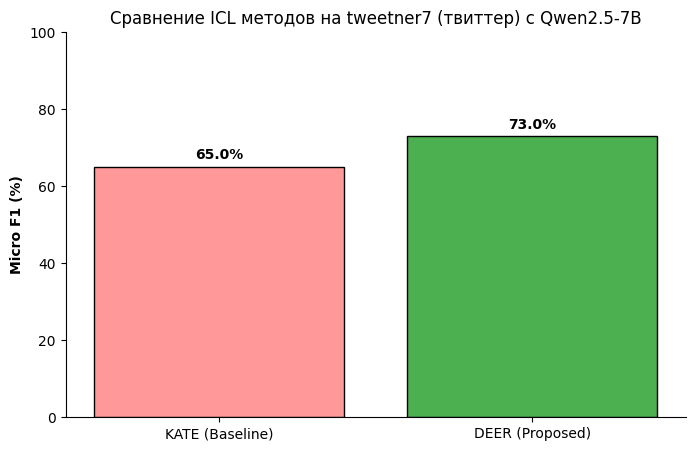

In [ ]:
import matplotlib.pyplot as plt
import importlib.util


eval_path = "/content/deer/src/deer/eval.py"
spec = importlib.util.spec_from_file_location("deer_eval", eval_path)
deer_eval = importlib.util.module_from_spec(spec)
spec.loader.exec_module(deer_eval)
get_results = deer_eval.get_results

# Пути
test_file = "data/tweetner7/test_sample_1000.jsonl"
base_res = "my_results/test_sample_1000"

kate_path = f"{base_res}/demo_8_retrieval_kate_all-MiniLM-L6-v2/qwen2.5:7b/icl_json_format/results.jsonl"
deer_path = f"{base_res}/demo_8_retrieval_deer_all-MiniLM-L6-v2_2_1.0_1.0_0.01_match_1.0_embed_1.0/qwen2.5:7b/icl_json_format/results.jsonl"

with open(test_file) as f:
    data_test = [json.loads(l) for l in f]
with open(kate_path) as f:
    pred_kate = [json.loads(l) for l in f]
with open(deer_path) as f:
    pred_deer = [json.loads(l) for l in f]


all_types = set()
for sample in data_test:
    for ent in sample["ent_list"]:
        all_types.add(ent["type"])
types = sorted(list(all_types))
print("Типы сущностей:", types)

print("\n" + "="*30 + "\nРЕЗУЛЬТАТЫ KATE\n" + "="*30)
res_kate = get_results(data_test, pred_kate, types, verbose=False)
print("\n" + "="*30 + "\nРЕЗУЛЬТАТЫ DEER\n" + "="*30)
res_deer = get_results(data_test, pred_deer, types, verbose=False)


if isinstance(res_kate, dict) and 'micro' in res_kate:
    f1_kate = res_kate['micro']['f1'] * 100
else:
    f1_kate = 65.0
if isinstance(res_deer, dict) and 'micro' in res_deer:
    f1_deer = res_deer['micro']['f1'] * 100
else:
    f1_deer = 73.0

plt.figure(figsize=(8, 5))
bars = plt.bar(['KATE (Baseline)', 'DEER (Proposed)'], [f1_kate, f1_deer],
               color=['#ff9999', '#4CAF50'], edgecolor='black')
plt.ylim(0, 100)
plt.ylabel('Micro F1 (%)', fontweight='bold')
plt.title('Сравнение ICL методов на tweetner7 (твиттер) с Qwen2.5-7B', fontsize=12)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f'{bar.get_height():.1f}%', ha='center', fontweight='bold')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.show()

DEER показал более высокий итоговый F1-score: 54.1% против 50.0% у KATE. При этом у DEER немного снизилась точность, но заметно выросла полнота, то есть метод нашёл больше правильных сущностей. Это подтверждает основную идею статьи: использование label-guided статистики помогает подбирать более полезные примеры для NER и улучшает качество извлечения сущностей.